11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5 | G: 1.626 | D: 0.482
Epoch 2/5 | G: 1.979 | D: 0.394
Epoch 3/5 | G: 1.070 | D: 1.111
Epoch 4/5 | G: 0.871 | D: 1.290
Epoch 5/5 | G: 1.250 | D: 0.953


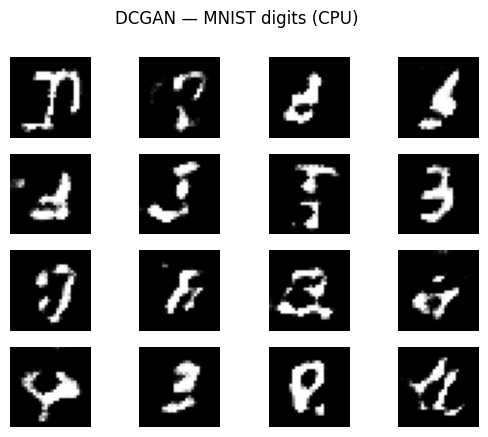

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ── Data: plain MNIST (simpler than Fashion → trains faster on CPU) ────────────
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = x_train[..., np.newaxis]
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(128)

LATENT_DIM = 64  # Reduced from 100 → faster

# ── Generator (smaller Dense layers) ─────────────────────────────────────────
G = tf.keras.Sequential([
    layers.Dense(7*7*128, input_shape=(LATENT_DIM,)),   # Halved filters
    layers.Reshape((7, 7, 128)),
    layers.Conv2DTranspose(64, 5, strides=2, padding='same', activation='relu'),
    layers.Conv2DTranspose(1,  5, strides=2, padding='same', activation='tanh'),
], name="Generator")

# ── Discriminator (smaller) ───────────────────────────────────────────────────
D = tf.keras.Sequential([
    layers.Conv2D(32, 5, strides=2, padding='same', input_shape=(28,28,1)),
    layers.LeakyReLU(0.2), layers.Dropout(0.3),
    layers.Conv2D(64, 5, strides=2, padding='same'),
    layers.LeakyReLU(0.2), layers.Dropout(0.3),
    layers.Flatten(), layers.Dense(1),
], name="Discriminator")

# ── Loss & Optimizers ─────────────────────────────────────────────────────────
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)
g_opt   = tf.keras.optimizers.Adam(1e-4)
d_opt   = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(real):
    noise = tf.random.normal([128, LATENT_DIM])
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake    = G(noise, training=True)
        g_loss  = loss_fn(tf.ones_like( D(fake)), D(fake))
        d_loss  = loss_fn(tf.ones_like( D(real)), D(real)) \
                + loss_fn(tf.zeros_like(D(fake)), D(fake))
    g_opt.apply_gradients(zip(gt.gradient(g_loss, G.trainable_variables), G.trainable_variables))
    d_opt.apply_gradients(zip(dt.gradient(d_loss, D.trainable_variables), D.trainable_variables))
    return g_loss, d_loss

# ── Train: only 5 epochs ──────────────────────────────────────────────────────
for epoch in range(5):                              # 5 instead of 30
    for batch in dataset:
        g_loss, d_loss = train_step(batch)
    print(f"Epoch {epoch+1}/5 | G: {g_loss:.3f} | D: {d_loss:.3f}")

# ── Output ────────────────────────────────────────────────────────────────────
imgs = G(tf.random.normal([16, LATENT_DIM]), training=False)
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow((imgs[i,:,:,0]+1)/2, cmap='gray')
    plt.axis('off')
plt.suptitle("DCGAN — MNIST digits (CPU)"); plt.show()